In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# read the dataset
df = pd.read_csv("height-weight.csv")
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


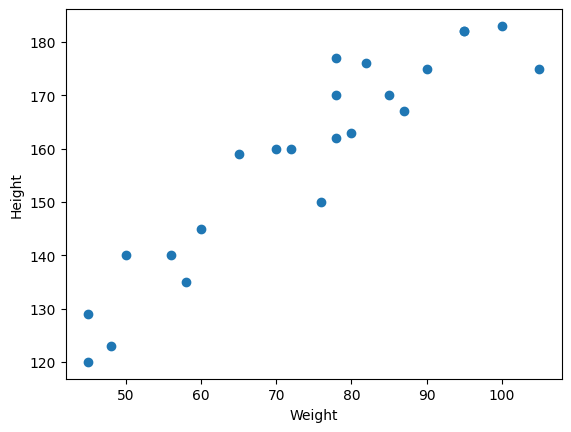

In [43]:
plt.scatter(x= df.Weight ,y =  df.Height )
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

# Problem statement >> i want to predict height based on weight 

In [44]:
x = df[["Weight"]]
y = df[["Height"]]

In [45]:
x,y

(    Weight
 0       45
 1       58
 2       48
 3       60
 4       70
 5       78
 6       80
 7       90
 8       95
 9       78
 10      82
 11      95
 12     105
 13     100
 14      85
 15      78
 16      50
 17      65
 18      76
 19      87
 20      45
 21      56
 22      72,
     Height
 0      120
 1      135
 2      123
 3      145
 4      160
 5      162
 6      163
 7      175
 8      182
 9      170
 10     176
 11     182
 12     175
 13     183
 14     170
 15     177
 16     140
 17     159
 18     150
 19     167
 20     129
 21     140
 22     160)

In [46]:
# train test split

from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y , test_size = 0.25 , random_state = 1 )

In [47]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [48]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [49]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [50]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [51]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((17, 1), (6, 1), (17, 1), (6, 1))

In [52]:
# scaling (optional) >> standardization >> fit_transform on train data and transform on test data
# if you use fit on test data , (that is wrong ) you are  doing data leeakage , avoid it 
# most of the ml model standard scaler is used as it deals with normal distribution 

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


In [55]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [56]:
# scaling should be done always after train test split
# target varible should not  be scaled 
# avoid scaling categorincal features 


x_train = scaler.fit_transform(x_train) # for train data use fit_transform
x_test = scaler.transform(x_test)             # for test data use transform

In [57]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [58]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

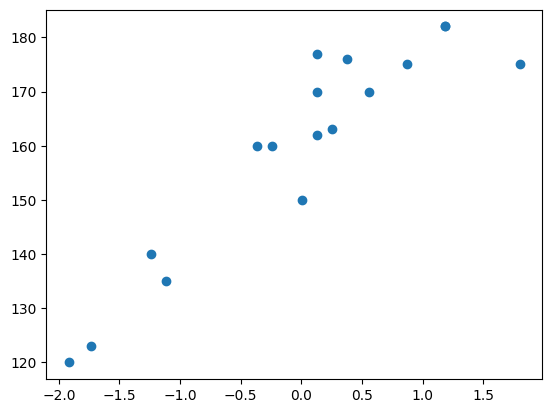

In [59]:
# scaling is optional >> why because it doesnt affect the distribution of the data

plt.scatter(x_train,y_train)

In [60]:
#  model Training

from sklearn.linear_model import LinearRegression

#linear regression parameters
#fit_intercept >> The best fit line will have intercept, by default it is true
#copy_X >> copy the original X_train and then build the model, it will not modify the original data
#n_jobs >>-1 means using all processors.
#positive>> When set to True, forces the coefficients to be positive.

#fit>> train the model
#predict>> test the model

#after building the model, you have attributes of the model
#coef_
#intercept

In [61]:
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
model.coef_

array([[17.7307072]])

In [64]:
model.intercept_

array([160.])

In [65]:
print("the slope or coeff of model is " , model.coef_)
print("the intercept of model is " , model.intercept_)

the slope or coeff of model is  [[17.7307072]]
the intercept of model is  [160.]


In [66]:
#prediction on train data
#interpretation of coef>> one unit increase in weight, on average the height increase by 17.73 units
#predicted height(y) on Xtrain = 160 + 17.73 * (Xtrain)

#predicted height(y) on Xtest = 160 + 17.73 * (Xtest)

In [67]:
# prediction on train

model.predict(x_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

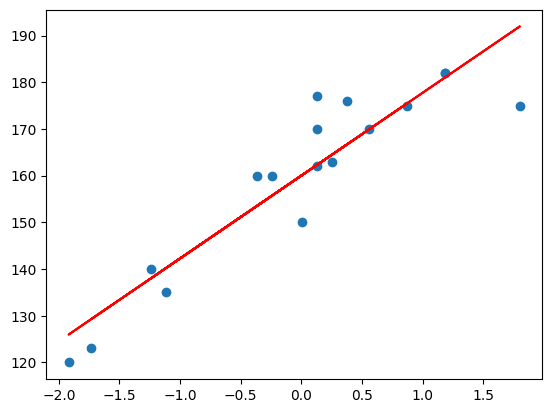

In [68]:
plt.scatter(x_train,y_train )
plt.plot(x_train , model.predict(x_train), "r")

In [69]:
y_pred_test = model.predict(x_test)
y_pred_test

array([[125.99571945],
       [147.97567266],
       [142.48068436],
       [186.44059077],
       [172.15362118],
       [131.49070775]])

In [70]:
y_pred_test, y_test

(array([[125.99571945],
        [147.97567266],
        [142.48068436],
        [186.44059077],
        [172.15362118],
        [131.49070775]]),
     Height
 20     129
 17     159
 3      145
 13     183
 19     167
 16     140)

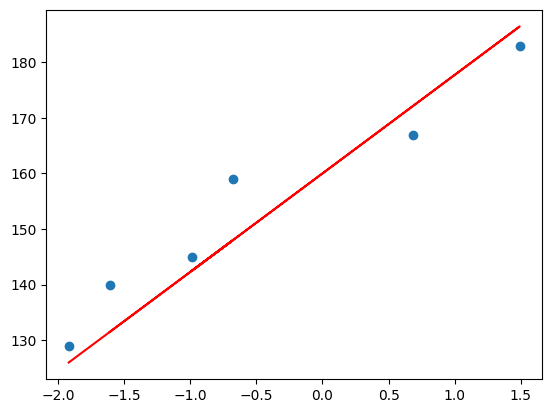

In [71]:
plt.scatter(x_test, y_test)
plt.plot(x_test,  model.predict(x_test),"r")

In [72]:
# perfomance metrics 

In [73]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [74]:
mean_absolute_error(y_test, y_pred_test)

5.608571289304838

In [75]:
mean_squared_error(y_test, y_pred_test)

41.285662830455514

In [76]:
rsq = r2_score(y_test,y_pred_test) #rsquare = 1-SSR/SST
rsq

0.8721036174256606

In [77]:
#adjusted rsquare 
#adjusted R2  = [(1-(1-rsquare)*n-1)/(n-k-1)] #n is no of observation and k is no of predictor variables

In [79]:
x_test.shape[1]

1

In [80]:
1-(1-rsq)*(len(y_test)-1)/(len(y_test)-x_test.shape[1] - 1)
#adjusted rsquare will be lesser than r square

0.8401295217820757

In [81]:
#assumption
#X-y should have linear relationship
#Observation should have no relation
#error should have constant variation
#error should be normally distributed
#features among themself should be least related

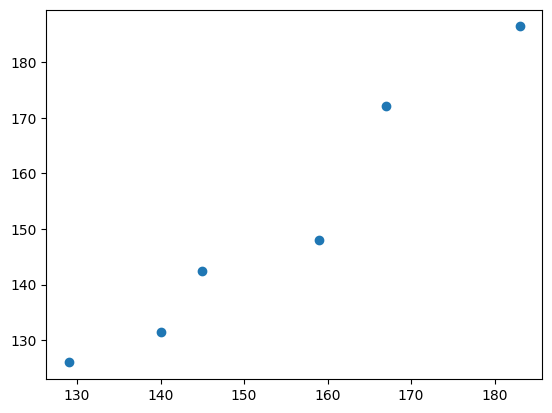

In [82]:
plt.scatter(y_test, y_pred_test)
#to chck if y_test and its prediction alighns

In [83]:
#error should have constant variation
#error should be normally distributed

In [84]:
error = y_test-y_pred_test
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12340\2272085197.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error) #approximately a normal distribution


<Axes: ylabel='Density'>

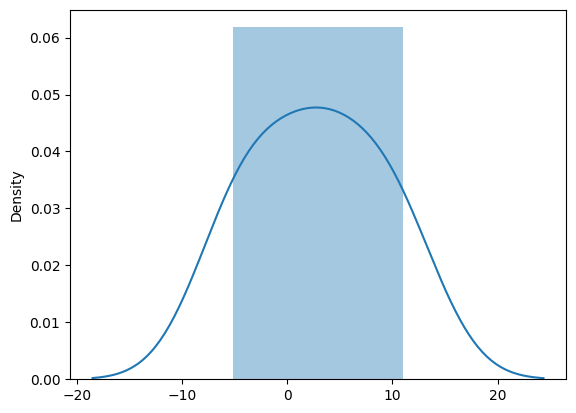

In [85]:
import seaborn as sns
sns.distplot(error) #approximately a normal distribution

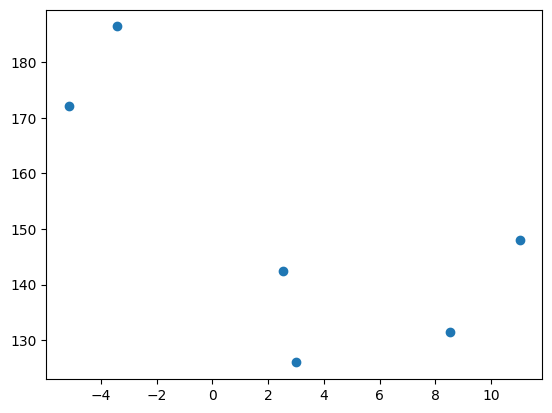

In [86]:
#to check constant variance
plt.scatter(error, y_pred_test)